# CBC Model

This notebook trains and evaluates the `cbc` model. It reads the local processed data file, performs cleaning, applies clinical rules, splits the data, and runs model selection.

In [9]:
# Imports and project path setup
from pathlib import Path
import sys, json
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Set ROOT path relative to project structure
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.diagnostic_models import MODEL_SPECS, build_io_schema, candidate_pipelines, evaluate_pipeline, predict_for_backend, train_model


In [10]:
# 1. Load Dataset
csv_path = ROOT / 'data' / 'real_processed' / 'cbc_nhanes_real.csv'
df = pd.read_csv(csv_path)
display(df.head())
print('Shape:', df.shape)


,age,sex,hemoglobin_g_dl,wbc_10e3_ul,platelets_10e3_ul,rbc_10e6_ul,mcv_fl,mch_pg,neutrophils_pct,lymphocytes_pct
0,43.0,male,15.7,4.7,259.0,5.19,87.4,30.2,46.1,40.8
1,66.0,male,15.2,6.3,221.0,4.59,95.8,33.0,57.3,25.4
2,44.0,female,13.8,5.7,235.0,4.86,82.5,28.3,58.5,29.9
3,5.0,female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.0,male,12.3,11.4,342.0,4.61,79.2,26.7,60.1,29.9


Shape: (8727, 10)


In [11]:
# 2. Cleaning and Labeling (Best Practice Dropna & Imputation)
spec = MODEL_SPECS['cbc']
# Drop only rows that miss critical variables needed to compute the target or sex demographics
critical_features = ['hemoglobin_g_dl', 'wbc_10e3_ul', 'platelets_10e3_ul', 'sex']
df = df.dropna(subset=critical_features).copy()

def label_cbc(row):
    urgent = (
        row['hemoglobin_g_dl'] < 8
        or row['wbc_10e3_ul'] < 2
        or row['wbc_10e3_ul'] > 20
        or row['platelets_10e3_ul'] < 50
        or row['platelets_10e3_ul'] > 800
    )
    follow_up = (
        row['hemoglobin_g_dl'] < 11
        or row['wbc_10e3_ul'] < 3.5
        or row['wbc_10e3_ul'] > 12
        or row['platelets_10e3_ul'] < 150
        or row['platelets_10e3_ul'] > 450
        or row['mcv_fl'] < 78
        or row['neutrophils_pct'] > 80
    )
    return 'urgent_review' if urgent else 'follow_up' if follow_up else 'within_reference'

df['cbc_risk'] = df.apply(label_cbc, axis=1)
print(df['cbc_risk'].value_counts(normalize=True).round(3))


cbc_risk
within_reference    0.855
follow_up           0.143
urgent_review       0.001
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis & Visualizations

Let's plot class distributions and analyze feature correlations before splitting and training.

C:\Users\frndas\AppData\Local\Temp\ipykernel_14580\2750666749.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='cbc_risk', order=['within_reference', 'follow_up', 'urgent_review'], palette='viridis')


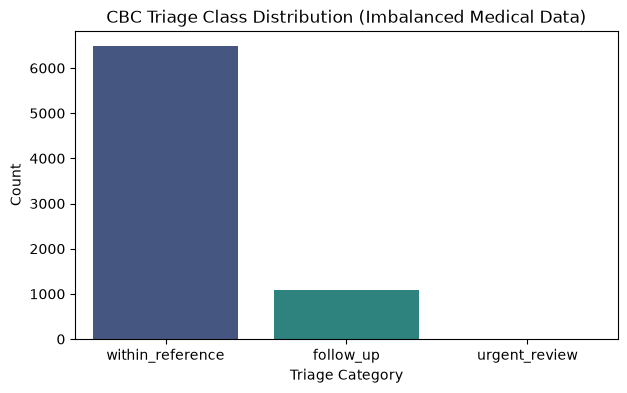

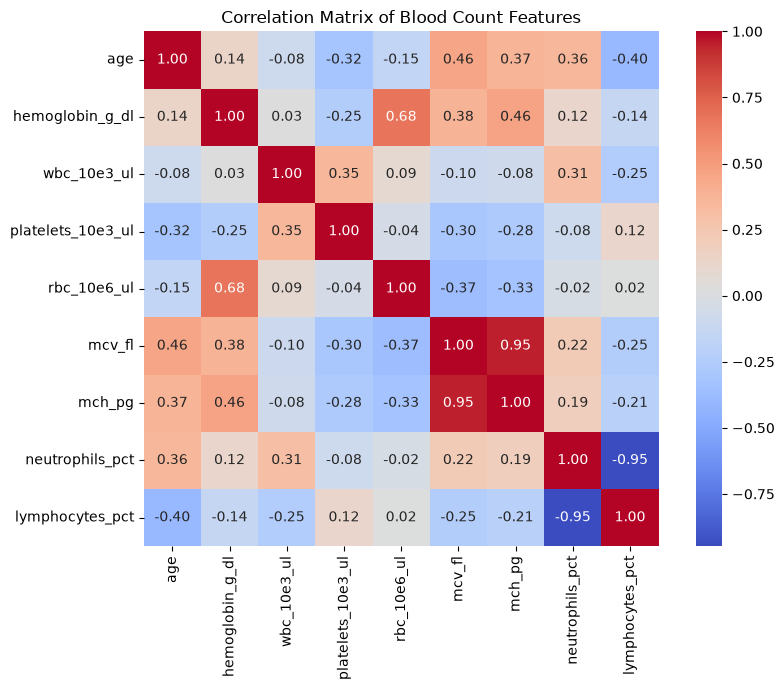

In [12]:
# Class Distribution Plot
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='cbc_risk', order=['within_reference', 'follow_up', 'urgent_review'], palette='viridis')
plt.title('CBC Triage Class Distribution (Imbalanced Medical Data)')
plt.xlabel('Triage Category')
plt.ylabel('Count')
plt.show()

# Feature Correlation Heatmap
plt.figure(figsize=(9, 7))
corr = df[spec.numeric_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Blood Count Features')
plt.tight_layout()
plt.show()


In [13]:
# 4. Train / Validation / Test Split
X = df[spec.numeric_features + spec.categorical_features]
y = df[spec.target]
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)
print(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')


Train: 5315, Val: 1139, Test: 1139


In [14]:
# 5. Preprocessing + Model Selection
candidate_results = {}
fitted = {}
for candidate_name, pipeline in candidate_pipelines(spec).items():
    pipeline.fit(X_train, y_train)
    fitted[candidate_name] = pipeline
    candidate_results[candidate_name] = evaluate_pipeline(pipeline, X_val, y_val, spec)

display(pd.DataFrame(candidate_results).T.sort_values(['positive_recall', 'macro_f1'], ascending=False))
best_name = sorted(candidate_results, key=lambda k: (candidate_results[k]['positive_recall'], candidate_results[k]['macro_f1'], candidate_results[k]['accuracy']), reverse=True)[0]
pipeline = fitted[best_name]
print('Best model:', best_name)


d:\Diagnostic agent\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,accuracy,macro_f1,positive_label,positive_recall
gradient_boosting,0.999122,0.88787,urgent_review,0.5
random_forest,0.998244,0.886685,urgent_review,0.5
rbf_svm,0.942054,0.763583,urgent_review,0.5
logistic_regression,0.76295,0.554697,urgent_review,0.5
hist_gradient_boosting,0.843723,0.373516,urgent_review,0.0


Best model: gradient_boosting


## 6. Feature Importance

Let's see which features contribute the most to the selected model's predictions.

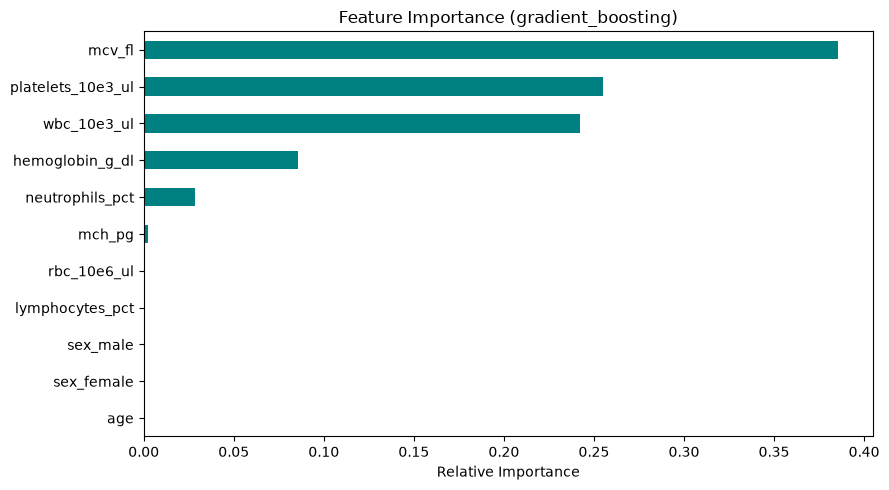

In [15]:
if hasattr(pipeline.named_steps['model'], 'feature_importances_'):
    importances = pipeline.named_steps['model'].feature_importances_
    cat_cols = list(pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(spec.categorical_features))
    feature_names = spec.numeric_features + cat_cols
    feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=True)
    plt.figure(figsize=(9, 5))
    feat_importances.plot(kind='barh', color='teal')
    plt.title(f'Feature Importance ({best_name})')
    plt.xlabel('Relative Importance')
    plt.tight_layout()
    plt.show()
else:
    print(f'Feature importance is not supported directly for {best_name}.')



VALIDATION
                  precision    recall  f1-score   support

       follow_up       0.99      1.00      1.00       163
   urgent_review       1.00      0.50      0.67         2
within_reference       1.00      1.00      1.00       974

        accuracy                           1.00      1139
       macro avg       1.00      0.83      0.89      1139
    weighted avg       1.00      1.00      1.00      1139


TEST
                  precision    recall  f1-score   support

       follow_up       0.99      1.00      1.00       164
   urgent_review       0.00      0.00      0.00         1
within_reference       1.00      1.00      1.00       974

        accuracy                           1.00      1139
       macro avg       0.66      0.67      0.67      1139
    weighted avg       1.00      1.00      1.00      1139



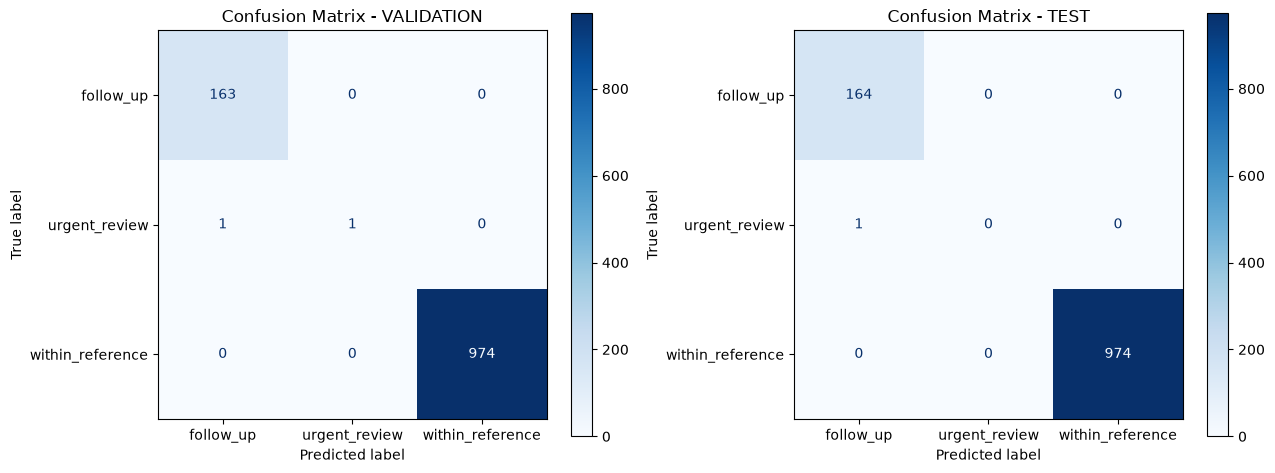

In [16]:
# 7. Evaluation Metrics & Confusion Matrices
for split_name, X_split, y_split in [('validation', X_val, y_val), ('test', X_test, y_test)]:
    preds = pipeline.predict(X_split)
    print('\n' + split_name.upper())
    print(classification_report(y_split, preds, zero_division=0))

# Visual Confusion Matrix Display
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (split_name, X_split, y_split) in zip(axes, [('validation', X_val, y_val), ('test', X_test, y_test)]):
    preds = pipeline.predict(X_split)
    cm = confusion_matrix(y_split, preds, labels=pipeline.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    ax.set_title(f'Confusion Matrix - {split_name.upper()}')
plt.tight_layout()
plt.show()


In [17]:
# 8. Save Model
joblib.dump(pipeline, ROOT / 'models' / 'cbc_pipeline.joblib')
print('Model saved successfully to models/cbc_pipeline.joblib.')


Model saved successfully to models/cbc_pipeline.joblib.


## 9. Backend Contract Prediction Simulation

Simulating how the backend would invoke this pipeline for real-world inference:

In [18]:
payload = {'age': 34, 'sex': 'female', 'hemoglobin_g_dl': 10.2, 'wbc_10e3_ul': 13.4, 'platelets_10e3_ul': 210, 'rbc_10e6_ul': 4.1, 'mcv_fl': 74, 'mch_pg': 25, 'neutrophils_pct': 82, 'lymphocytes_pct': 12}
result = predict_for_backend('cbc', payload, ROOT)
print(json.dumps(result, indent=2, ensure_ascii=False))


{
  "model_name": "cbc",
  "prediction": "follow_up",
  "probabilities": {
    "follow_up": 0.9999987502051061,
    "urgent_review": 6.063715548197259e-09,
    "within_reference": 1.243731178397249e-06
  },
  "triage_action": "ask_follow_up_questions",
  "explanation": "The cbc model found a non-urgent abnormal pattern and the chatbot should ask follow-up questions.",
  "safety_disclaimer": "Educational decision support only, not a diagnosis. Urgent symptoms need urgent care."
}
